# DAY2 마지막 진단 — 초기 용량 의존 억제

가설: Batch1의 초기 용량–수명 관계에 대한 의존을 줄이면 내부 오차가 증가하더라도 Batch2의 과대 예측을 줄일 수 있다.

원논문에서 초기 총 용량과 수명의 관계가 약했고, 현재 데이터에서도 초기 용량 분포가 배치마다 달랐다는 근거로 가설을 세웠다. 가설은 이전 외부 진단을 본 이후의 탐색이며 처음 보는 독립 Test가 아니다. [원논문](https://www.nature.com/articles/s41560-019-0356-8)

**보고서 연결:** 이 노트북은 해당 실험 단계의 실행 기록이다. 기존 셀 분리와 프로토콜 분리 결과를 함께 해석한 전체 결론은 [DAY2 보고서](../outputs/day2/DAY2_REPORT.md)에 있다.


In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.day2_capacity_penalty import main
main()  # 완료된 결과가 있으면 재학습·재평가하지 않는다.
OUT = ROOT / "outputs/day2/capacity_penalty"
result = json.loads((OUT / "results.json").read_text())
display(pd.DataFrame([result["versions"]]))

Saved diagnostic exists; no repeated training or evaluation.


,python,numpy,pandas,sklearn
0,3.11.15,2.4.6,3.0.6,1.9.1


## 1. 무엇을 고정하고 변경했는가?

학습28/Hold-out8/기존CV5/seed42, 5개 특징, log10 수명 Target, 다른 특징의 Ridge 벌점1을 유지했다. 초기 용량 계수 벌점만10·100으로 늘렸다.

각 CV 학습 폴드 안에서 결측 대체·표준화를 학습한 뒤 초기 용량 열을 1/√벌점으로 조정했다. 이를 다시 표준화하지 않았다. 원 표준화 특징의 계수로 환산하면 초기 용량 계수제곱에만 벌점이 더 크게 적용된다. 전체 모델 규제 강화와 다르다.

기존 모델 점수와 완전 제거 조건의 CV는 재사용했다. 제거 조건은 이번에 학습용28개로 학습해 Hold-out/Batch2를 확인했다. 신규CV10회, 학습용28개fit3회. 추가 강도 탐색과 36개 재학습은 하지 않았다.

,title,cv_mape_pct,holdout_mape_pct,batch2_mape_pct,batch2_bias_cycles
0,기존 규제,7.6979,3.4212,38.1976,190.7287
1,초기 용량 규제 10배,7.8321,3.9315,35.4332,173.4137
2,초기 용량 규제 100배,9.1348,5.8490,29.8296,138.4287
3,초기 용량 완전 제거,9.8054,6.6077,27.9241,125.2116


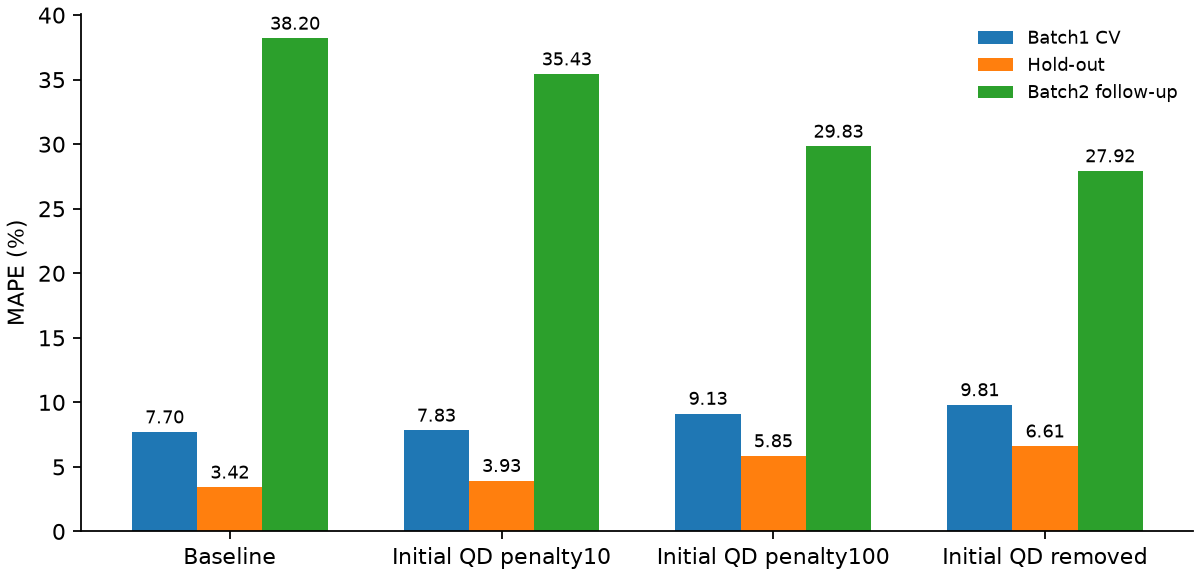

In [2]:
comparison = pd.read_csv(OUT / "comparison.csv")
display(comparison[["title", "cv_mape_pct", "holdout_mape_pct", "batch2_mape_pct", "batch2_bias_cycles"]].round(4))
display(Image(filename=str(OUT / "comparison.png")))

## 2. 실제 결과

초기 용량 의존 억제 시 CV7.70→7.83→9.13%, Hold-out3.42→3.93→5.85%로 악화했지만 Batch2는38.20→35.43→29.83%로 개선했다. 완전 제거는CV9.81%, Hold-out6.61%, Batch2 27.92%였다.

즉 이번 고정 조건에서는 내부 정확도를 양보하고 외부 오차를 줄이는 패턴이 관측됐다. 다음 표에서 계수와 과대 예측의 감소가 함께 나타났는지 확인한다.

In [3]:
coefficients = pd.read_csv(OUT / "coefficients.csv")
display(coefficients.loc[coefficients.feature.eq("qd_initial_median")].round(6))
segments = pd.read_csv(OUT / "segments.csv")
display(segments.loc[segments.evaluation.eq("Test (Batch 2)")].round(3))

,condition,feature,coefficient_standardized,coefficient_original_units
2,baseline,qd_initial_median,0.029025,3.473440
7,penalty10,qd_initial_median,0.021816,2.610750
12,penalty100,qd_initial_median,0.006262,0.749424


,condition,evaluation,life_band,n,mape_pct,mean_prediction_minus_actual
0,baseline,Test (Batch 2),<=500,28,40.018,179.428
1,baseline,Test (Batch 2),500-1000,8,40.320,297.311
2,baseline,Test (Batch 2),>1000,3,15.551,11.985
5,penalty10,Test (Batch 2),<=500,28,37.873,169.382
6,penalty10,Test (Batch 2),500-1000,8,35.257,257.016
7,penalty10,Test (Batch 2),>1000,3,13.135,-11.901
10,penalty100,Test (Batch 2),<=500,28,33.505,148.900
11,penalty100,Test (Batch 2),500-1000,8,25.016,175.733
12,penalty100,Test (Batch 2),>1000,3,8.362,-58.779
15,removed,Test (Batch 2),<=500,28,31.844,141.099


## 3. 도메인 근거 → 개입 → 결과 → 한계

초기 총 용량은 열화 정보와 같지 않고, 초기 상태와 측정 조건도 반영할 수 있다. 현재 데이터에서 배치별 초기 용량 차이가 있었고, 그 계수의 규제를 강화하자 초기 용량 의존과 Batch2 과대 예측이 함께 감소했다. Batch1에서 도움이 되는 관계가 배치 간 일반화에는 불리할 수 있다는 가설과 부합한다.

하지만 다른 계수도 재추정되므로 초기 용량 하나의 독립적인 인과효과로 보지 않는다. 단수명 사례 부재가 유일한 원인이라고 확정할 수도 없다.

500 이하28개에서 평균 과대 예측은 기존179.43사이클, 100배규제148.90사이클, 완전제거141.10사이클로 여전히 크다. 완전제거27.92%도 기존 단일분산 모델26.19%를 넘지 못한다. 목표9.1%는 달성하지 못했다.

Batch2 점수로 최종 모델을 다시 고르지 않고 기존 Batch1 CV 선택 MAPE 모델을 유지한다. 이 실험은 후속 진단으로 기록하며 추가 실험을 종료한다. 전체 정리는 `outputs/day2/DAY2_REPORT.md`, 상세 결과는 `outputs/day2/DAY2_REPORT.md`에 있다.